<a href="https://colab.research.google.com/github/ABDULLAH-104/E-commerce-Funnel-Investigation/blob/main/E_commerce_Funnel_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction (ML) — Full Pipeline

Upload `customer_churn.csv` when prompted, then Run All.

In [2]:
from google.colab import files
uploaded = files.upload()   # select customer_churn.csv


Saving customer_churn.csv to customer_churn.csv


In [3]:
"""
PROJECT: Customer Churn Prediction (ML)
Full pipeline: load -> clean -> EDA -> preprocess -> train -> evaluate -> export for Power BI

Run this in Google Colab (upload customer_churn.csv when prompted) or locally
with the CSV in the same folder.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# -----------------------------------------------------------------
# If running in Colab, uncomment these two lines to upload the file
# -----------------------------------------------------------------
# from google.colab import files
# uploaded = files.upload()

## STEP 1: LOAD DATA

In [4]:
df = pd.read_csv("customer_churn.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (3015, 14)
  customer_id  tenure_months  monthly_charges  total_charges   contract_type  \
0       C3618             17            39.86         695.09  Month-to-month   
1       C1021             64            59.28        3803.01        One year   
2       C1371             29            55.29        1604.47        Two year   
3       C2606             55            80.51        4422.63  Month-to-month   
4       C2781             38            51.73        1997.42  Month-to-month   

  internet_service    payment_method  support_tickets tech_support  \
0              DSL     Bank transfer                2          Yes   
1      Fiber optic     Bank transfer                3           No   
2               No      Mailed check                0           No   
3              DSL       Credit card                2           No   
4      Fiber optic  Electronic check                1           No   

  online_security  senior_citizen partner paperless_billing churn  
0           

## STEP 2: CLEAN DATA

In [5]:
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# fill missing total_charges with median
df["total_charges"] = df["total_charges"].fillna(df["total_charges"].median())

# drop exact duplicates
df = df.drop_duplicates()

print("\nShape after cleaning:", df.shape)
print("\nChurn distribution:\n", df["churn"].value_counts(normalize=True))


Missing values:
 customer_id           0
tenure_months         0
monthly_charges       0
total_charges        60
contract_type         0
internet_service      0
payment_method        0
support_tickets       0
tech_support          0
online_security       0
senior_citizen        0
partner               0
paperless_billing     0
churn                 0
dtype: int64

Duplicate rows: 15

Shape after cleaning: (3000, 14)

Churn distribution:
 churn
No     0.613
Yes    0.387
Name: proportion, dtype: float64


## STEP 3: EDA (quick summary, not deep-dive -- this is a modeling project)

In [6]:
churn_by_contract = pd.crosstab(df["contract_type"], df["churn"], normalize="index")
print("\nChurn rate by contract type:\n", churn_by_contract)

churn_by_internet = pd.crosstab(df["internet_service"], df["churn"], normalize="index")
print("\nChurn rate by internet service:\n", churn_by_internet)


Churn rate by contract type:
 churn                 No       Yes
contract_type                     
Month-to-month  0.435601  0.564399
One year        0.759409  0.240591
Two year        0.913115  0.086885

Churn rate by internet service:
 churn                   No       Yes
internet_service                    
DSL               0.668545  0.331455
Fiber optic       0.553756  0.446244
No                0.649913  0.350087


## STEP 4: PREPARE FEATURES

In [7]:
model_df = df.drop(columns=["customer_id"]).copy()

# target: Yes/No -> 1/0
model_df["churn"] = model_df["churn"].map({"Yes": 1, "No": 0})

categorical_cols = [
    "contract_type", "internet_service", "payment_method",
    "tech_support", "online_security", "partner", "paperless_billing"
]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

X = model_df.drop(columns=["churn"])
y = model_df["churn"]

print("\nFeature columns:", list(X.columns))


Feature columns: ['tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'senior_citizen', 'contract_type_One year', 'contract_type_Two year', 'internet_service_Fiber optic', 'internet_service_No', 'payment_method_Credit card', 'payment_method_Electronic check', 'payment_method_Mailed check', 'tech_support_Yes', 'online_security_Yes', 'partner_Yes', 'paperless_billing_Yes']


## STEP 5: TRAIN/TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# keep customer_id aligned with the test set for the Power BI export later
test_customer_ids = df.loc[X_test.index, "customer_id"]

## STEP 6: BASELINE MODEL - LOGISTIC REGRESSION

In [9]:
# Logistic Regression needs scaled features to converge properly and
# to treat all features fairly (tenure_months and monthly_charges are
# on very different scales otherwise).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression ===")
print("Accuracy :", round(accuracy_score(y_test, log_preds), 3))
print("Precision:", round(precision_score(y_test, log_preds), 3))
print("Recall   :", round(recall_score(y_test, log_preds), 3))
print("F1 Score :", round(f1_score(y_test, log_preds), 3))
print("ROC AUC  :", round(roc_auc_score(y_test, log_proba), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))


=== Logistic Regression ===
Accuracy : 0.72
Precision: 0.632
Recall   : 0.659
F1 Score : 0.646
ROC AUC  : 0.781
Confusion Matrix:
 [[279  89]
 [ 79 153]]


## STEP 7: STRONGER MODEL - RANDOM FOREST

In [10]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=8)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Accuracy :", round(accuracy_score(y_test, rf_preds), 3))
print("Precision:", round(precision_score(y_test, rf_preds), 3))
print("Recall   :", round(recall_score(y_test, rf_preds), 3))
print("F1 Score :", round(f1_score(y_test, rf_preds), 3))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_proba), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

# Random Forest generally wins here -- it captures non-linear
# interactions (e.g. month-to-month contract + low tenure together)
# better than logistic regression can.


=== Random Forest ===
Accuracy : 0.695
Precision: 0.617
Recall   : 0.556
F1 Score : 0.585
ROC AUC  : 0.758
Confusion Matrix:
 [[288  80]
 [103 129]]


## STEP 8: FEATURE IMPORTANCE (why do customers churn?)


Top 10 churn drivers:
 contract_type_Two year             0.264200
total_charges                      0.134774
tenure_months                      0.131587
monthly_charges                    0.117539
contract_type_One year             0.111791
support_tickets                    0.052422
internet_service_Fiber optic       0.034943
tech_support_Yes                   0.033288
paperless_billing_Yes              0.019395
payment_method_Electronic check    0.018419
dtype: float64


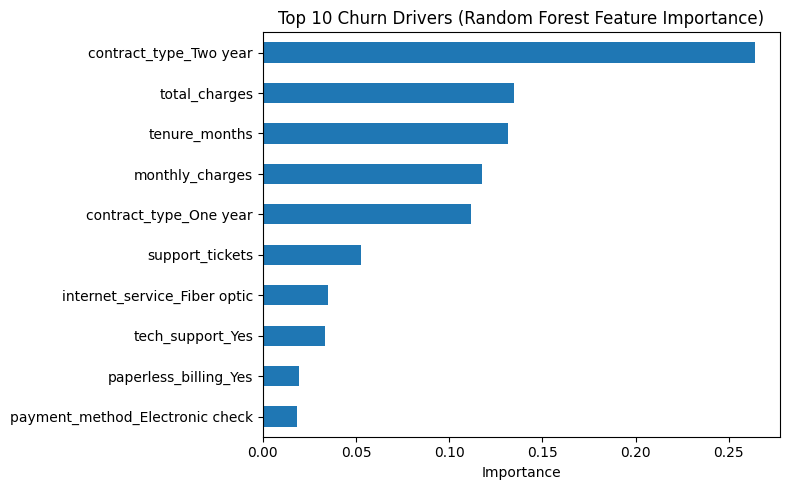

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 10 churn drivers:\n", importances.head(10))

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Churn Drivers (Random Forest Feature Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

## STEP 9: EXPORT RESULTS FOR POWER BI

In [12]:
# 9a. Per-customer predictions -- this is the main table for Power BI.
#     Includes actual churn, predicted churn, and churn PROBABILITY
#     (probability is more useful in BI than a hard 0/1 label, since
#     it lets you rank/filter "highest risk" customers).
results_df = df.loc[X_test.index].copy()
results_df["actual_churn"] = y_test.values
results_df["predicted_churn"] = rf_preds
results_df["churn_probability"] = np.round(rf_proba, 4)
results_df["risk_band"] = pd.cut(
    results_df["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)
results_df.to_csv("churn_predictions.csv", index=False)

# 9b. Feature importance table -- for a "top churn drivers" chart in Power BI
importance_df = importances.reset_index()
importance_df.columns = ["feature", "importance"]
importance_df.to_csv("feature_importance.csv", index=False)

# 9c. Model performance summary -- for a KPI card / metrics table in Power BI
metrics_df = pd.DataFrame([
    {"model": "Logistic Regression",
     "accuracy": accuracy_score(y_test, log_preds),
     "precision": precision_score(y_test, log_preds),
     "recall": recall_score(y_test, log_preds),
     "f1_score": f1_score(y_test, log_preds),
     "roc_auc": roc_auc_score(y_test, log_proba)},
    {"model": "Random Forest",
     "accuracy": accuracy_score(y_test, rf_preds),
     "precision": precision_score(y_test, rf_preds),
     "recall": recall_score(y_test, rf_preds),
     "f1_score": f1_score(y_test, rf_preds),
     "roc_auc": roc_auc_score(y_test, rf_proba)},
])
metrics_df.to_csv("model_metrics.csv", index=False)

print("\nExported files: churn_predictions.csv, feature_importance.csv, model_metrics.csv")
print("\nDone. Import these 3 CSVs into Power BI to build the dashboard.")


Exported files: churn_predictions.csv, feature_importance.csv, model_metrics.csv

Done. Import these 3 CSVs into Power BI to build the dashboard.
